# 03 - Results Visualization

This notebook visualizes the validation performance of the baseline echocardiography EF estimation model.

It reuses the same preprocessing, split logic, and saved model from Notebook 02.
Main goals:
- Reload validation data
- Recompute validation predictions
- Visualize prediction quality
- Analyze errors
- Show best and worst prediction examples

In [1]:
from pathlib import Path
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import load_model

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path("../").resolve()

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "echo2022"
TRAIN_CSV_PATH = DATA_ROOT / "train_data.csv"

TRAIN_4CH_DIR = DATA_ROOT / "train_data" / "4CH"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
MODELS_DIR = RESULTS_DIR / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_CSV_PATH exists:", TRAIN_CSV_PATH.exists())
print("TRAIN_4CH_DIR exists:", TRAIN_4CH_DIR.exists())
print("Model exists:", (MODELS_DIR / "baseline_best.keras").exists())

PROJECT_ROOT: /Users/emirarslan/Downloads/lab task/echo-project
TRAIN_CSV_PATH exists: True
TRAIN_4CH_DIR exists: True
Model exists: True


In [3]:
train_df = pd.read_csv(TRAIN_CSV_PATH)

print("train_df shape:", train_df.shape)
print(train_df.columns.tolist())

train_df.head()

train_df shape: (400, 2)
['Patient_number', 'LV_ef']


,Patient_number,LV_ef
0,patient001,58.9
1,patient002,37.3
2,patient003,65.3
3,patient004,38.4
4,patient005,58.5


In [4]:
possible_id_cols = [col for col in train_df.columns if "patient" in col.lower() or "id" in col.lower()]
print("Possible ID columns:", possible_id_cols)

train_df = train_df.copy()
id_col = possible_id_cols[0]

train_df["patient_str"] = train_df[id_col].astype(str).str.extract(r"(\d+)", expand=False)
train_df["patient_str"] = "patient" + train_df["patient_str"].str.zfill(3)

label_map = dict(zip(train_df["patient_str"], train_df["LV_ef"]))

print("Number of labels:", len(label_map))
list(label_map.items())[:5]

Possible ID columns: ['Patient_number']
Number of labels: 400


[('patient001', 58.9),
 ('patient002', 37.3),
 ('patient003', 65.3),
 ('patient004', 38.4),
 ('patient005', 58.5)]

In [5]:
train_4ch_files = sorted([p for p in TRAIN_4CH_DIR.glob("*.npy")])

print("Train 4CH files:", len(train_4ch_files))
print("Sample train file:", train_4ch_files[0].name)

Train 4CH files: 400
Sample train file: patient001_4CH_sequence.npy


In [6]:
def extract_patient_id_from_filename(filepath):
    return filepath.stem.split("_")[0]

In [7]:
missing_labels = []
for fp in train_4ch_files:
    patient_id = extract_patient_id_from_filename(fp)
    if patient_id not in label_map:
        missing_labels.append(fp.name)

print("Missing labels:", len(missing_labels))
missing_labels[:10]

Missing labels: 0


[]

In [8]:
train_records = []
for fp in train_4ch_files:
    patient_id = extract_patient_id_from_filename(fp)
    if patient_id in label_map:
        train_records.append({
            "filepath": fp,
            "patient_id": patient_id,
            "label": float(label_map[patient_id])
        })

train_records_df = pd.DataFrame(train_records)

print("Usable train samples:", len(train_records_df))
train_records_df.head()

Usable train samples: 400


,filepath,patient_id,label
0,/Users/emirarslan/Downloads/lab task/echo-proj...,patient001,58.9
1,/Users/emirarslan/Downloads/lab task/echo-proj...,patient002,37.3
2,/Users/emirarslan/Downloads/lab task/echo-proj...,patient003,65.3
3,/Users/emirarslan/Downloads/lab task/echo-proj...,patient004,38.4
4,/Users/emirarslan/Downloads/lab task/echo-proj...,patient005,58.5


In [9]:
train_split_df, val_split_df = train_test_split(
    train_records_df,
    test_size=0.2,
    random_state=SEED
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

print("Train split:", len(train_split_df))
print("Val split:", len(val_split_df))
val_split_df.head()

Train split: 320
Val split: 80


,filepath,patient_id,label
0,/Users/emirarslan/Downloads/lab task/echo-proj...,patient210,77.7
1,/Users/emirarslan/Downloads/lab task/echo-proj...,patient281,62.3
2,/Users/emirarslan/Downloads/lab task/echo-proj...,patient034,56.5
3,/Users/emirarslan/Downloads/lab task/echo-proj...,patient211,54.1
4,/Users/emirarslan/Downloads/lab task/echo-proj...,patient094,47.7


In [10]:
IMG_SIZE = (256, 256)
N_FRAMES = 10

In [11]:
def load_sequence(filepath, n_frames=N_FRAMES, img_size=IMG_SIZE):
    seq = np.load(filepath)

    selected = seq[:n_frames]

    if selected.shape[0] < n_frames:
        pad_count = n_frames - selected.shape[0]
        pad_frame = selected[-1] if selected.shape[0] > 0 else np.zeros(seq.shape[1:], dtype=seq.dtype)
        padding = np.stack([pad_frame] * pad_count, axis=0)
        selected = np.concatenate([selected, padding], axis=0)

    resized = np.zeros((n_frames, img_size[0], img_size[1]), dtype=np.float32)

    for i, frame in enumerate(selected):
        resized[i] = cv2.resize(frame, img_size, interpolation=cv2.INTER_LINEAR)

    if resized.max() > 0:
        resized = resized / resized.max()

    resized = np.expand_dims(resized, axis=-1)

    return resized

In [12]:
MODEL_PATH = MODELS_DIR / "baseline_best.keras"
model = load_model(MODEL_PATH)

print("Loaded model from:", MODEL_PATH)
model.summary()

Loaded model from: /Users/emirarslan/Downloads/lab task/echo-project/results/models/baseline_best.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 256, 256,   │           320 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 256, 256,   │           128 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 128, 128,   │             0 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 128, 128,   │        18,496 │
│ (TimeDistributed)               │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 128, 128,   │           256 │
│ (TimeDistributed)               │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 64, 64, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 64, 64,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 128)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,349 (1.65 MB)

 Trainable params: 144,385 (564.00 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 288,772 (1.10 MB)

In [13]:
val_predictions = []
val_targets = []

for _, row in val_split_df.iterrows():
    x = load_sequence(row["filepath"])
    pred = model.predict(np.expand_dims(x, axis=0), verbose=0)[0, 0]

    val_predictions.append(pred)
    val_targets.append(row["label"])

val_predictions = np.array(val_predictions)
val_targets = np.array(val_targets)

print("Validation samples:", len(val_predictions))
print("First 5 predictions:", val_predictions[:5])
print("First 5 targets:", val_targets[:5])

Validation samples: 80
First 5 predictions: [51.17544  51.175667 51.17591  51.175453 51.17571 ]
First 5 targets: [77.7 62.3 56.5 54.1 47.7]


In [14]:
rmse = np.sqrt(mean_squared_error(val_targets, val_predictions))
mae = mean_absolute_error(val_targets, val_predictions)
r2 = r2_score(val_targets, val_predictions)

print("Validation RMSE:", rmse)
print("Validation MAE:", mae)
print("Validation R2:", r2)

Validation RMSE: 11.164773770954898
Validation MAE: 9.046946468353273
Validation R2: -0.04175969790416856


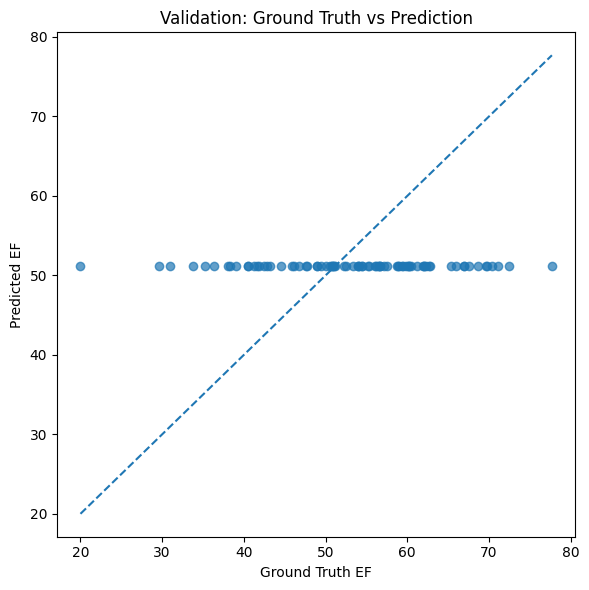

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(val_targets, val_predictions, alpha=0.7)

plt.plot(
    [np.min(val_targets), np.max(val_targets)],
    [np.min(val_targets), np.max(val_targets)],
    linestyle="--"
)

plt.xlabel("Ground Truth EF")
plt.ylabel("Predicted EF")
plt.title("Validation: Ground Truth vs Prediction")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "val_gt_vs_pred_recomputed.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
val_results_df = val_split_df.copy()
val_results_df["prediction"] = val_predictions
val_results_df["error"] = val_results_df["prediction"] - val_results_df["label"]
val_results_df["abs_error"] = np.abs(val_results_df["error"])

val_results_df.head()

,filepath,patient_id,label,prediction,error,abs_error
0,/Users/emirarslan/Downloads/lab task/echo-proj...,patient210,77.7,51.175442,-26.524558,26.524558
1,/Users/emirarslan/Downloads/lab task/echo-proj...,patient281,62.3,51.175667,-11.124333,11.124333
2,/Users/emirarslan/Downloads/lab task/echo-proj...,patient034,56.5,51.175911,-5.324089,5.324089
3,/Users/emirarslan/Downloads/lab task/echo-proj...,patient211,54.1,51.175453,-2.924547,2.924547
4,/Users/emirarslan/Downloads/lab task/echo-proj...,patient094,47.7,51.175709,3.475709,3.475709


In [17]:
print("Prediction mean:", val_predictions.mean())
print("Prediction std:", val_predictions.std())
print("Target mean:", val_targets.mean())
print("Target std:", val_targets.std())

Prediction mean: 51.17508
Prediction std: 0.0010040253
Target mean: 53.40999999999999
Target std: 10.93871107580779


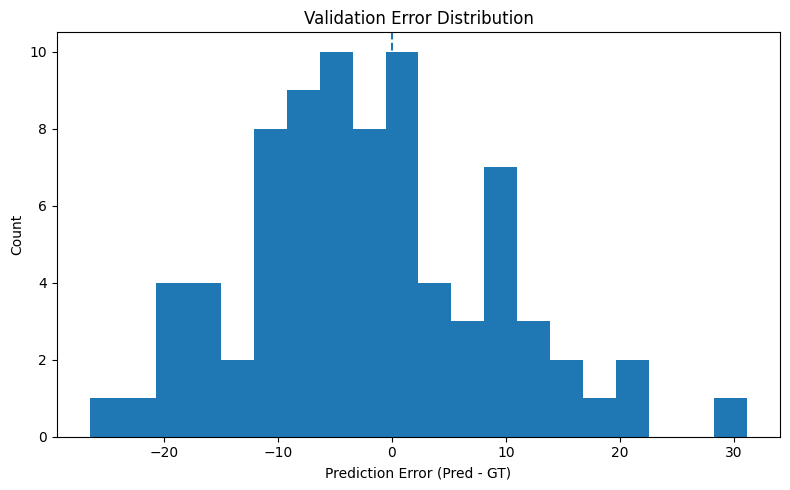

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(val_results_df["error"], bins=20)
plt.axvline(0, linestyle="--")
plt.xlabel("Prediction Error (Pred - GT)")
plt.ylabel("Count")
plt.title("Validation Error Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "val_error_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

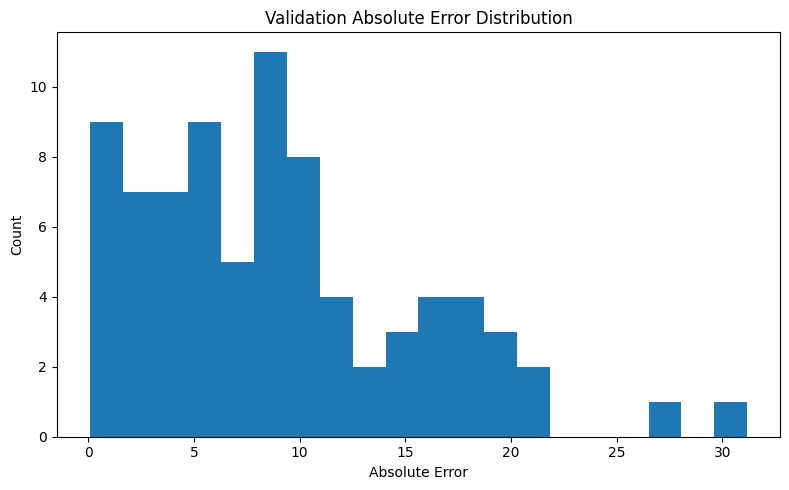

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(val_results_df["abs_error"], bins=20)
plt.xlabel("Absolute Error")
plt.ylabel("Count")
plt.title("Validation Absolute Error Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "val_abs_error_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

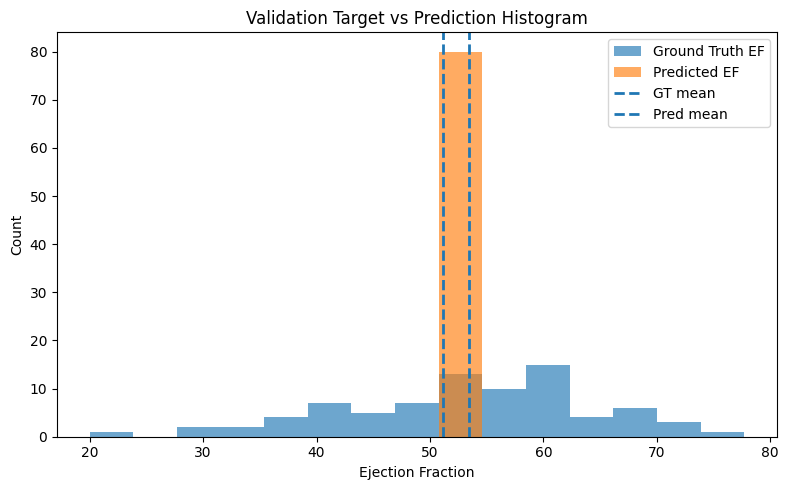

In [20]:
plt.figure(figsize=(8, 5))
bins = np.linspace(
    min(val_targets.min(), val_predictions.min()),
    max(val_targets.max(), val_predictions.max()),
    16
)

plt.hist(val_targets, bins=bins, alpha=0.65, label="Ground Truth EF")
plt.hist(val_predictions, bins=bins, alpha=0.65, label="Predicted EF")
plt.axvline(val_targets.mean(), linestyle="--", linewidth=2, label="GT mean")
plt.axvline(val_predictions.mean(), linestyle="--", linewidth=2, label="Pred mean")
plt.xlabel("Ejection Fraction")
plt.ylabel("Count")
plt.title("Validation Target vs Prediction Histogram")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "val_gt_vs_pred_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

In [21]:
ef_group_summary = (
    val_results_df.assign(
        ef_group=pd.cut(
            val_results_df["label"],
            bins=[-np.inf, 40, 55, np.inf],
            labels=["Low EF (<40)", "Mid EF (40-55)", "High EF (>=55)"],
            right=False,
        )
    )
    .groupby("ef_group", observed=False)
    .agg(
        n_samples=("label", "size"),
        mean_target_ef=("label", "mean"),
        mean_prediction=("prediction", "mean"),
        mean_error=("error", "mean"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        max_abs_error=("abs_error", "max"),
    )
    .reset_index()
)

ef_group_summary.to_csv(METRICS_DIR / "ef_group_error_summary.csv", index=False)
display(ef_group_summary)

,ef_group,n_samples,mean_target_ef,mean_prediction,mean_error,mean_abs_error,median_abs_error,max_abs_error
0,Low EF (<40),9,33.455556,51.175434,17.719878,17.719878,15.975377,31.175808
1,Mid EF (40-55),32,48.265625,51.175095,2.909468,4.153164,3.124602,10.675327
2,High EF (>=55),39,62.235897,51.174988,-11.060912,11.060912,9.224036,26.524558


In [22]:
best_cases = val_results_df.sort_values("abs_error").head(5)
worst_cases = val_results_df.sort_values("abs_error", ascending=False).head(5)

print("Best cases:")
display(best_cases[["patient_id", "label", "prediction", "error", "abs_error"]])

print("Worst cases:")
display(worst_cases[["patient_id", "label", "prediction", "error", "abs_error"]])

Best cases:


,patient_id,label,prediction,error,abs_error
49,patient174,51.1,51.175819,0.075819,0.075819
37,patient343,51.0,51.174610,0.174610,0.174610
47,patient182,50.9,51.174622,0.274622,0.274622
16,patient279,50.8,51.174816,0.374816,0.374816
75,patient247,50.8,51.175438,0.375438,0.375438


Worst cases:


,patient_id,label,prediction,error,abs_error
61,patient295,20.0,51.175808,31.175808,31.175808
0,patient210,77.7,51.175442,-26.524558,26.524558
33,patient058,29.6,51.174984,21.574984,21.574984
77,patient370,72.5,51.175247,-21.324753,21.324753
30,patient396,30.9,51.175468,20.275468,20.275468


In [23]:
def show_case_frames(case_row, title_prefix="", frame_indices=(0, 3, 6, 9)):
    x = load_sequence(case_row["filepath"])

    plt.figure(figsize=(14, 3))
    for i, frame_idx in enumerate(frame_indices):
        plt.subplot(1, len(frame_indices), i + 1)
        plt.imshow(x[frame_idx, :, :, 0], cmap="gray")
        plt.title(f"Frame {frame_idx}")
        plt.axis("off")

    plt.suptitle(
        f"{title_prefix} | {case_row['patient_id']} | GT={case_row['label']:.2f}, "
        f"Pred={case_row['prediction']:.2f}, AbsErr={case_row['abs_error']:.2f}",
        y=1.05
    )
    plt.tight_layout()
    plt.show()

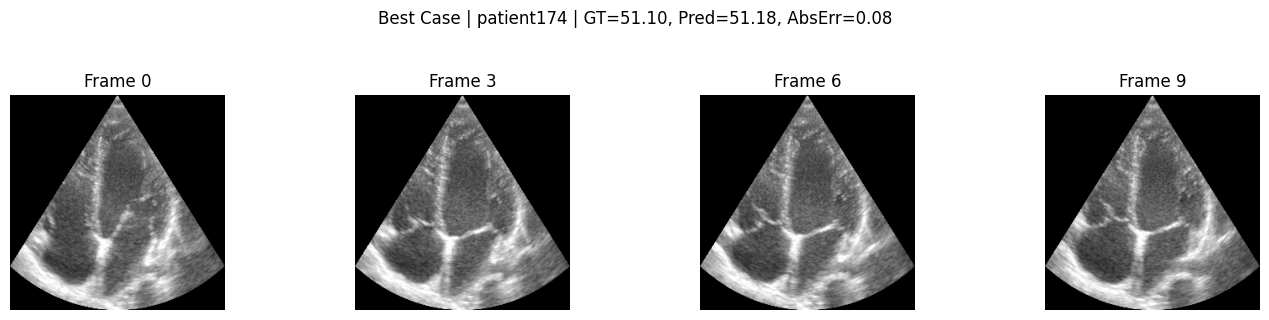

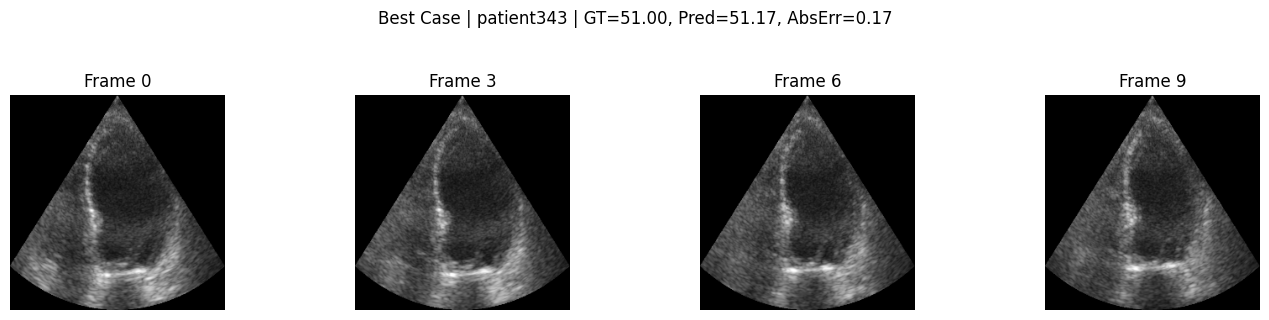

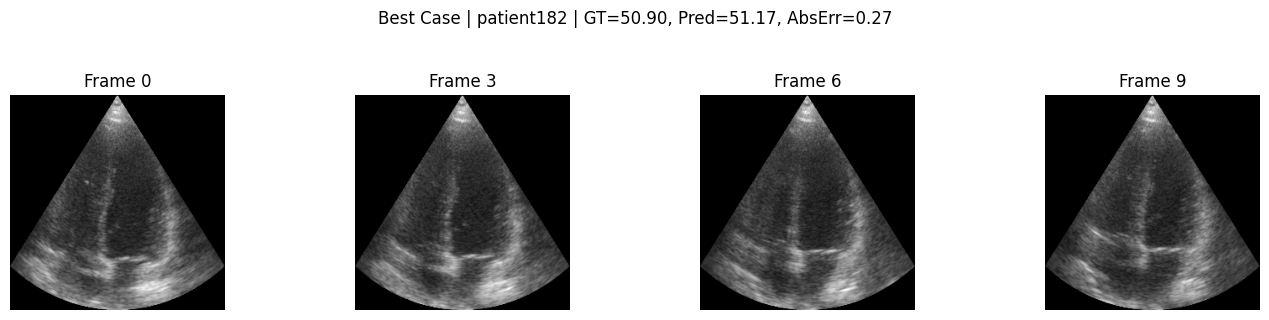

In [24]:
for _, row in best_cases.head(3).iterrows():
    show_case_frames(row, title_prefix="Best Case")

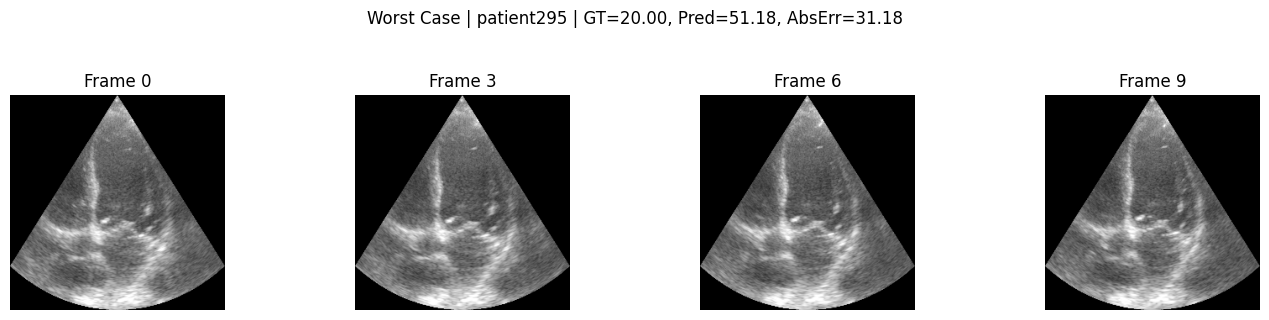

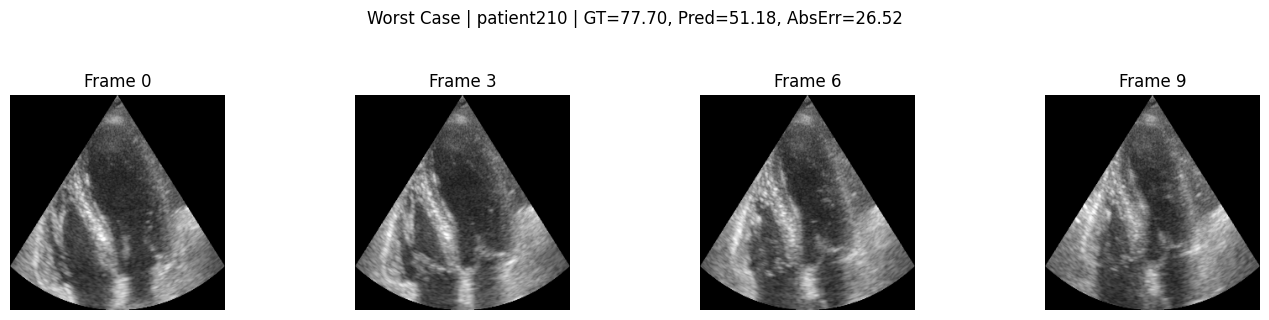

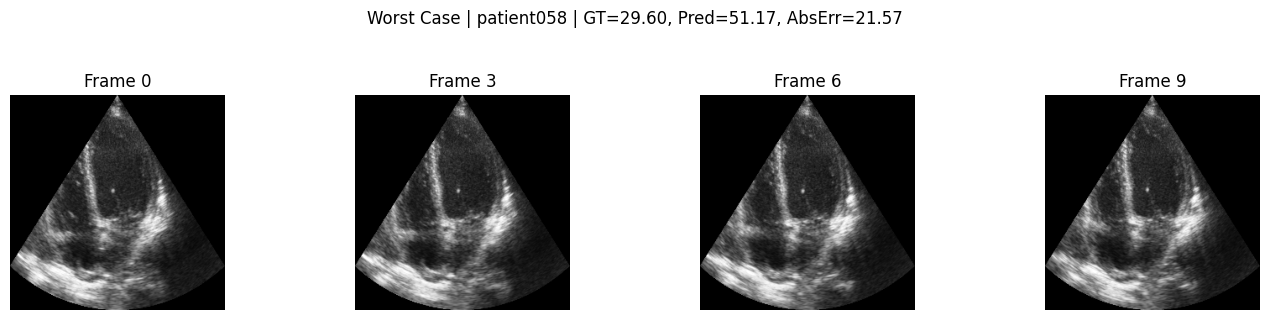

In [25]:
for _, row in worst_cases.head(3).iterrows():
    show_case_frames(row, title_prefix="Worst Case")

In [26]:
top10_worst = val_results_df.sort_values("abs_error", ascending=False).head(10)
top10_best = val_results_df.sort_values("abs_error").head(10)

top10_worst.to_csv(METRICS_DIR / "top10_worst_validation_cases.csv", index=False)
top10_best.to_csv(METRICS_DIR / "top10_best_validation_cases.csv", index=False)

print("Saved:")
print(METRICS_DIR / "top10_worst_validation_cases.csv")
print(METRICS_DIR / "top10_best_validation_cases.csv")

Saved:
/Users/emirarslan/Downloads/lab task/echo-project/results/metrics/top10_worst_validation_cases.csv
/Users/emirarslan/Downloads/lab task/echo-project/results/metrics/top10_best_validation_cases.csv


In [27]:
print("==== Validation Summary ====")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")
print()
print(f"Best case abs error : {best_cases.iloc[0]['abs_error']:.4f}")
print(f"Worst case abs error: {worst_cases.iloc[0]['abs_error']:.4f}")
print(f"Median abs error    : {val_results_df['abs_error'].median():.4f}")

==== Validation Summary ====
RMSE: 11.1648
MAE : 9.0469
R2  : -0.0418

Best case abs error : 0.0758
Worst case abs error: 31.1758
Median abs error    : 8.3522


## Baseline Diagnosis

- Validation RMSE is around 11.16, MAE is around 9.05, and R2 is negative.
- Predictions collapse near the dataset mean instead of tracking the full EF range.
- The scatter plot shows weak correlation between ground truth and prediction.
- Errors are smallest in the mid-EF region and much larger in low/high EF groups.
- Likely causes: limited temporal sampling, single-view input, simple architecture, and no chamber-focused segmentation.
- This makes the notebook useful for failure analysis, not as a clinically reliable endpoint.
